## Introduction
**In this notebook, I will be addressing the trends in pre-snap offensive motion effectiveness and frequency during NFL hurry up situations. I define these situations as any play where the possessing team faces time pressure on the current drive and the game clock is actively running. These usually result from drives at the end of halves where the previous play was a run or completion in bounds. I found that there are interesting interactions between pre-snap motion timing, snap timing, and the possession team's probability of winning the game. Offensive motion does not take significant time to run, and its positive effect on plays' success likely outweigh the slight negative effect of the time used. In this dataset, teams were under-utilizing motion on offense during late-game drives despite its overall effectiveness. As a result, the findings demonstrated in this notebook can help inform when it is an effective use of a team's precious time in a hurry-up situation to run pre-snap motion, and how offensive play callers can improve their strategies based on the conclusions.** 

## Data cleaning
I began my analysis with the player play dataframe, and created indicators for how many different offensive players went in pre-snap motion on each play. This is a critical variable for the rest of the analysis. The following process was used to determine which plays to categorize as 'hurry up' plays.

Next, I found the exact times that certain important events for each play occurred, based on the player tracking dataframes. Main events for each play are line set, shift, man in motion, ball snap, and 'play over'. There are a number of ways for a play to end, but I consider them all equally in this analysis. I removed all events that weren't in those lists, and found the specific time that the play began, as that sometimes is not explicitly listed.

Now I had the exact times that a player went in motion, the ball was snapped, and the play was over. Based on these, I calculated how much time elapsed between each event. After doing so, I then merged the time differences dataframe with the one that showed whether there was motion on the play and the one that has the play-by-play descriptive data. This resulted in a dataframe with one row per play and each row containing all of the important variables. Especially important were the variable denoting how long elapsed between motion start and snap and the variable denoting how long it took from the end of the previous play to snap the ball. To ensure I am comparing like-to-like plays regardless of situation, I am only considering passing plays in this analysis. Furthermore, I am limiting my sample to passes that traveled 40 yards or less in the air. This removes some outliers that tend to occur in time pressure situations, like desperation Hail Marys.

## Defining hurry-up
There are three types of time pressure situations:
- Two minutes or less remaining in second quarter
- Four minutes or less remaining in fourth quarter and possession team tied or trailing by one score or less
- Six minutes or less remaining in fourth quarter and possession team tied or trailing by two scores or less

A play will not be considered hurry up if:
- The clock has stopped for any reason (ball carrier went out of bounds, pass was incomplete, timeout was called)
- The play is a two-point conversion
- The possessing team is already in field goal range and does not need more than a field goal to go ahead
- The possessing team is already winning by three scores or more in the second half

All other plays in time pressure situations will be considered hurry up. Thus we can contrast plays in late-half, time-pressured situations where the clock was stopped and where it was not, to see if there are significant differences in strategy that result from a running clock. We can also see how different these situations are from "normal", non-time-pressured situations.

## Analysis

When I separate the plays' timing variables by whether the play occurred in a time pressure or a hurry up situation, we can see the results in Table 1. This table contains only plays where there were 0 or 1 players in motion (94.3% of all plays in the dataset), because of the difficulties in calculating time of motion with multiple players.

The 'Play Clock At Snap' column serves to show the effectiveness of separating hurry up from non-hurry up situations, even within time pressure situations. There is no difference between the first two rows in that column but a big difference to the third, because teams are only hurrying to snap the ball in those situations. The clock will always be stopped in the second row, so there is no need for them to snap the ball particularly quickly.

Furthermore, even in situations where the clock is stopped, teams are underutilizing motion when facing time pressure. Their motion rate of 22.74% when the clock is stopped is very similar to the rate of 20.64% when it is not, despite the fact that they have the luxury of extra time to run their full offense. We would expect to see rates around 40% if teams were truly behaving as normal. In Tables 2 and 3, we see that running any motion is correlated with significant improvements in offensive performance (measured by Win Probability Added per play) regardless of whether there was time pressure or not. Thus, there is no clear reason for this drop-off in motion rates under time pressure when the clock is stopped. My hypothesis is that offenses have an incorrect assumption that they have to move quickly any time the clock is low, not just when it's running, and thus do not run the full range of their offensive plays after clock stoppages. However, I cannot say just from this data what the true underlying reason here is.

-- Table 1 --
| timePressure| hurryUp | % of Plays w/ Motion | Play Clock At Snap (sec) | Time Of Motion (sec) | Total Time to Snap (sec)|
| ------------|---------|-------|---------|---------------|--------|
|False| False|39.74%|10.28|2.99|34.11|
|True| False|22.74%|10.70|2.81|N/A|
|True| True|20.64%|16.75|3.50|22.18|

-- Table 2 --

| timePressure|hurryUp|anyMotion|Win Prob. Added per play (%)|
|--|--|--|--|
|False|False|False|0.160|
|False|False|True|0.364|

-- Table 3 --

| timePressure|hurryUp|anyMotion|Win Prob. Added per play (%)|
|--|--|--|--|
|True|False|False|-0.361|
|True|False|True|0.122|
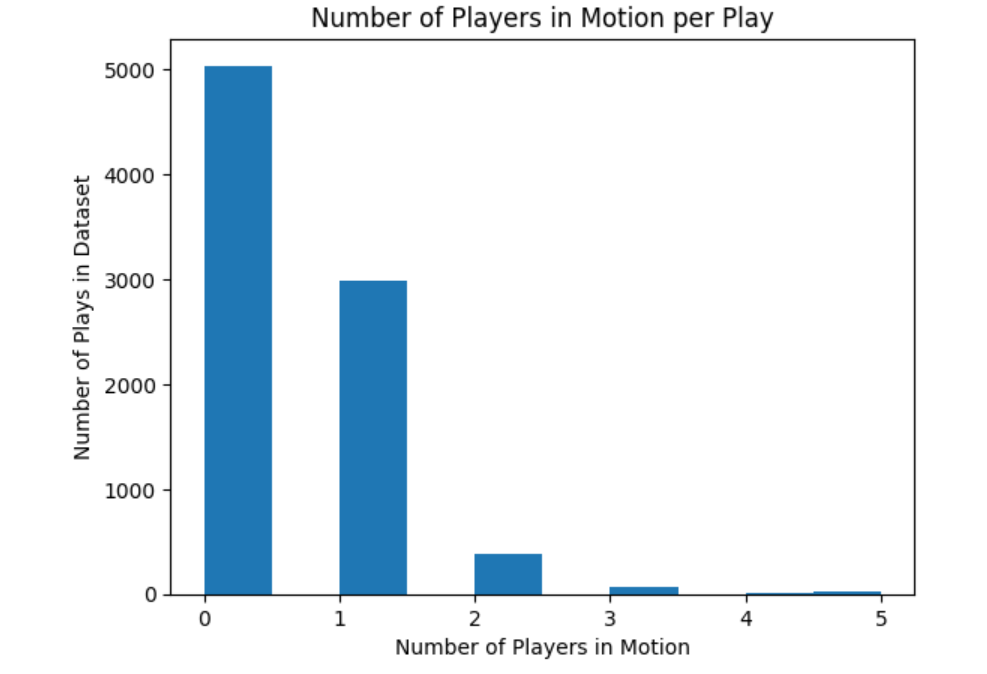

To test whether time to run motion or total time between plays makes a significant impact on team success in hurry up situations, I fit a simple OLS regression model to test this relationship. Using total time to snap as the independent variable (X) and win probability added as the dependent variable (y), I found that the coefficient on X was -.296 with a p-value of 0.000. Thus, each additional second taken to run a play in hurry up offense is correlated with a decrease of 0.296 percentage points in terms of win probability, and this result is statistically significant. When using Expected Points Added as the dependent variable instead, we see essentially identical results. As a result, we can conclude that it is very important to use time efficiently in hurry-up situations, which tracks with intuition. However, in regular situations (not hurry up), there is no significant relationship between the variables, and if anything, using additional time actually improves the plays' outcomes.

-- Figure 1 --

More importantly for this analysis, running motion seems to create a significantly longer time to snap. In Table 4, there is a marked increase in time to snap between plays with motion and without, in both hurry up and normal situations. The two-sided independent t-tests that I ran to compare these sample means yielded p-values of below 0.01, leading to the conclusion that there is a statistically significant effect of motion which increases the amount of time to snap.

-- Table 4 --
|hurryUp|anyMotion|Total Time To Snap (sec.)|
|--|--|--|
|True|False|20.99|
|True|True|26.82|
|--|--|--|
|False|False|32.69|
|False|True|35.94|

Interestingly, the actual time it takes to run motion does not seem to impact win probability or expected points added, even when the clock is running. The p-values on motion time in the regressions using WPA and EPA as dependent variables are 0.642 and 0.773 respectively (when hurryUp = True), suggesting that taking additional time for motion does not seriously hinder a team's performance even with limited time remaining. It is unlikely that the extra time for motion plays a role in team success aside from its direct impact on overall time to snap. Because the average time between motion and snap is just slightly over 3 seconds, it is rarely the case that this would cause a team to run out of time to score all by itself. With lower and lower amounts of game time remaining, however, using these additional seconds pre-snap would be more and more detrimental. Thus there is an important tradeoff to make when offenses are considering whether to run motion, which relies heavily on time remaining and how quickly they think they can execute motion. It appears that teams in time pressure situations are incorrectly analyzing this tradeoff, due to an overall lack of motion under clock stoppages. Given more time, I would have looked more deeply into which teams and players can execute motion the quickest and how this affects the success of their drives.

Assumptions I made during the process included limiting the analysis to 0 or 1 players in motion per play (as opposed to 2+, which happens in a non-trivial number of plays). If I included all plays, there would probably be a higher overall time of motion due to the increased complexity of the play, and more variation in time of motion/time to snap. I am also only looking at passing plays, and incorporating running plays would likely lead to altered results. However, these are infrequent in time pressured situations as they typically cannot stop the clock, and I wanted to ensure that I was considering plays of similar types across the different situations.
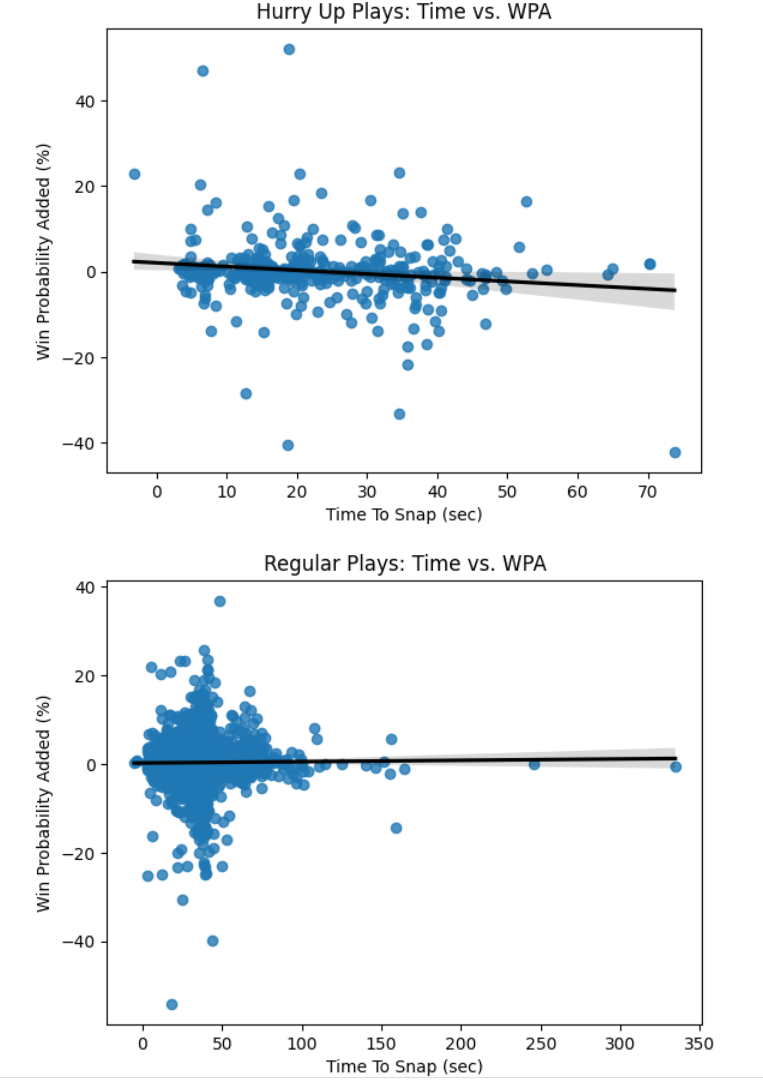
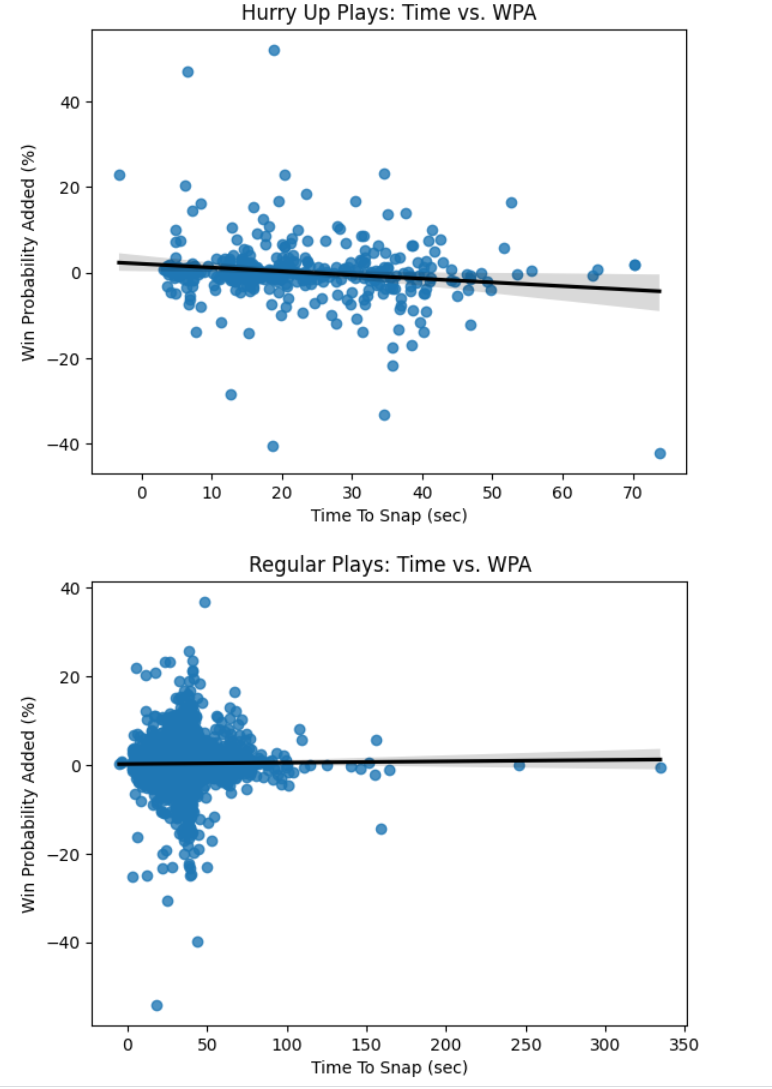
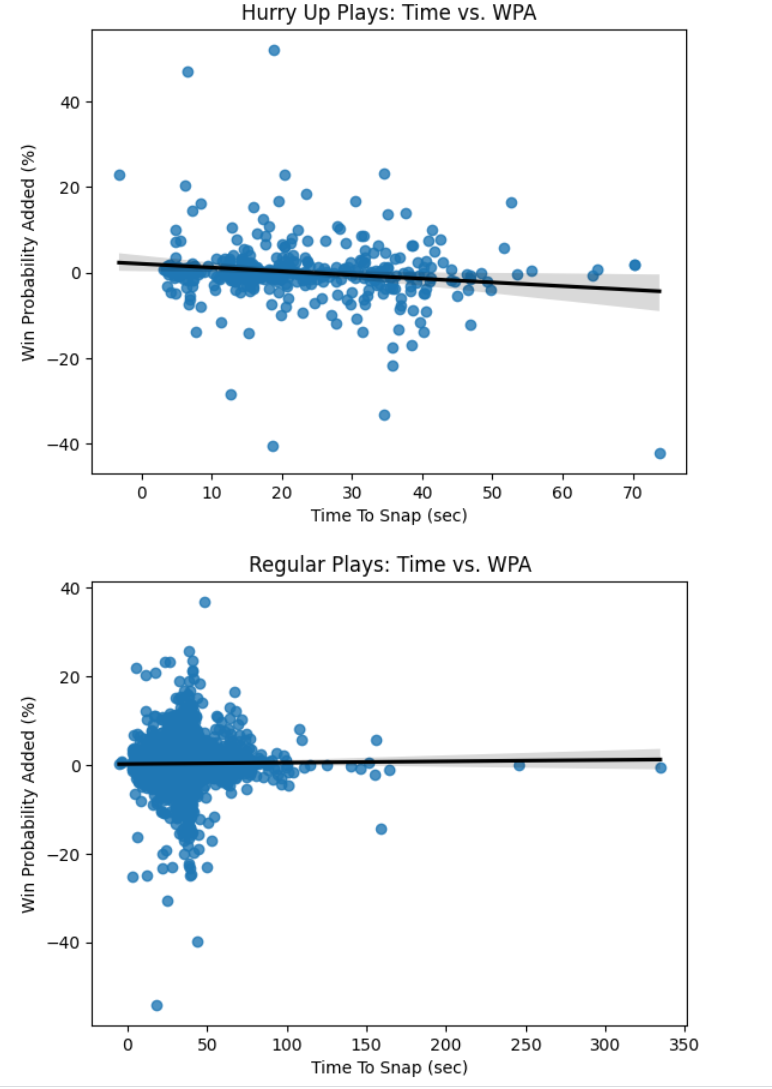
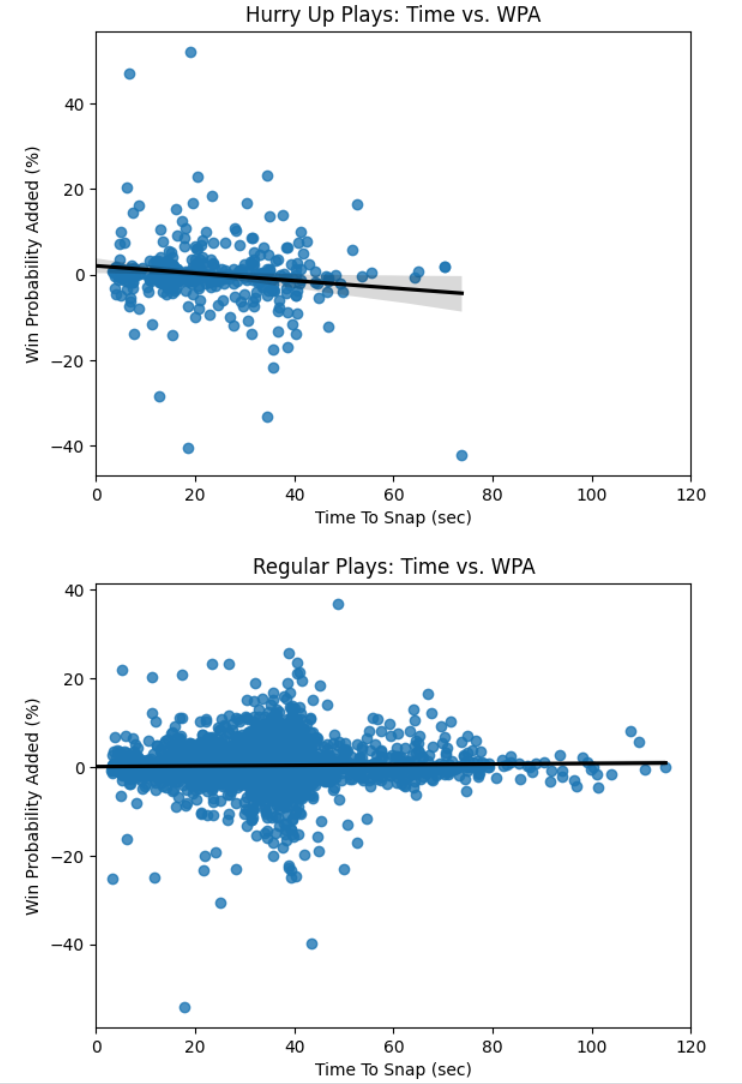
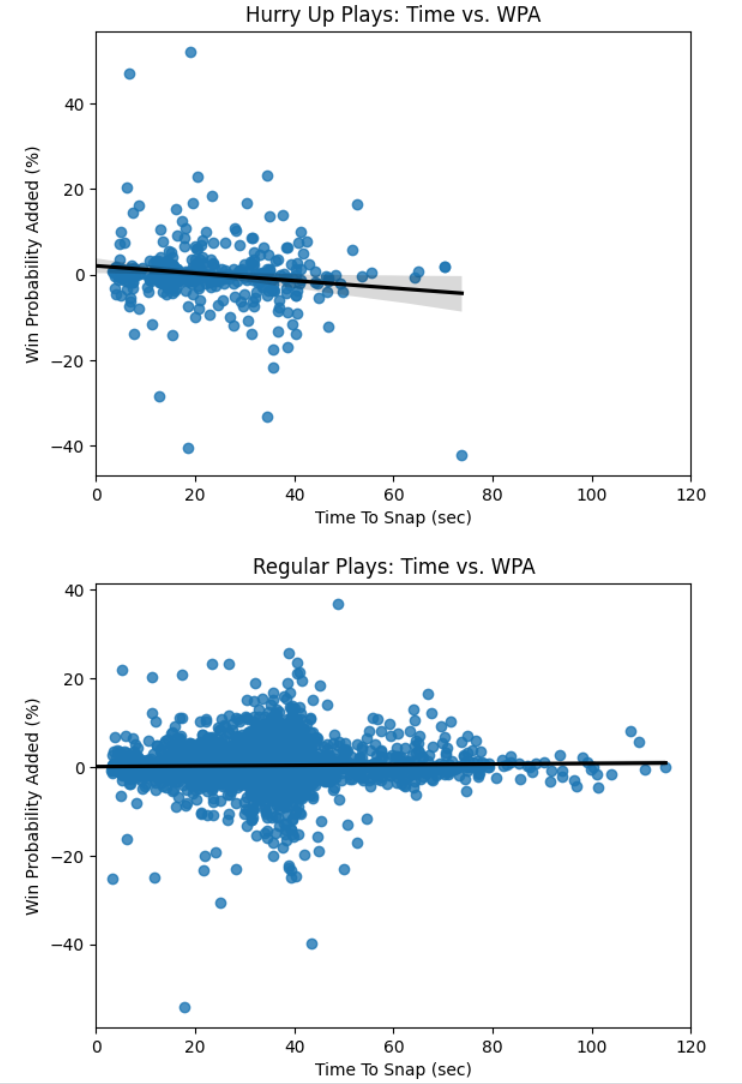
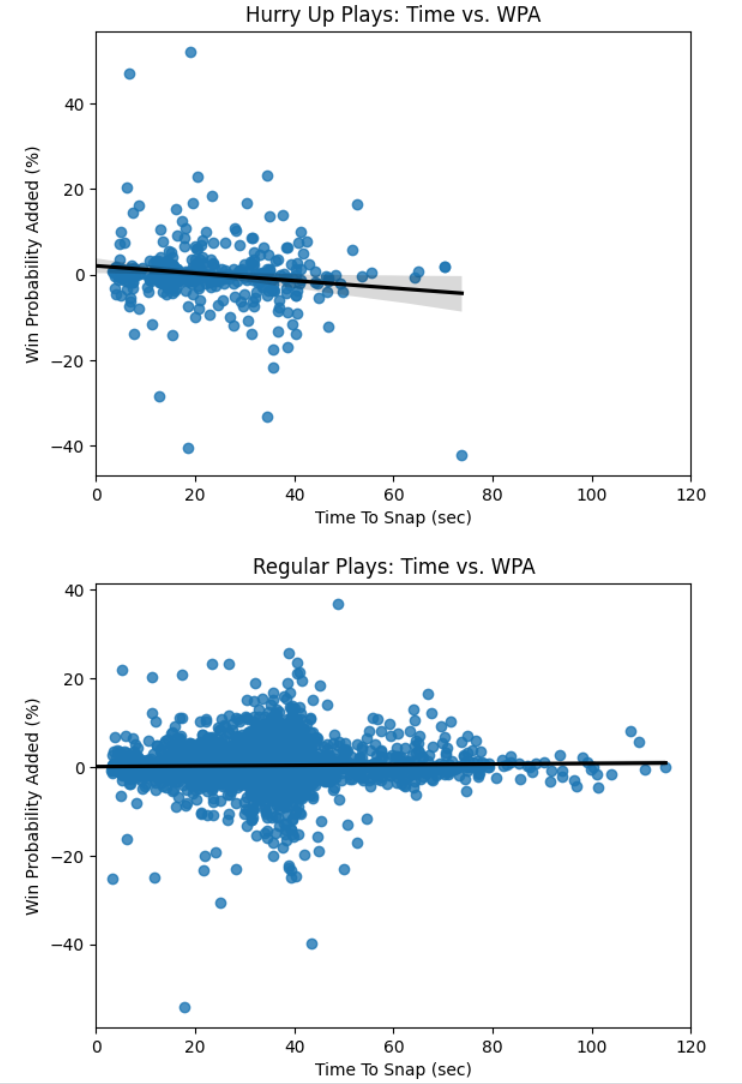
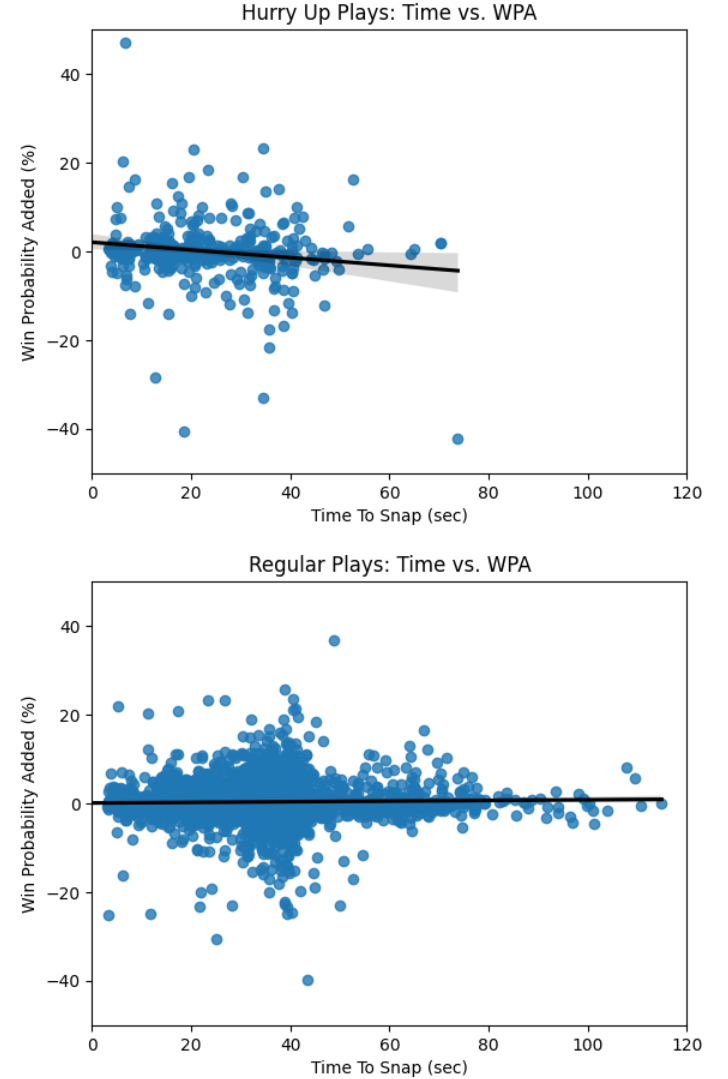

## Appendix

In [ ]:

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind
import statsmodels.api as sm
import os

In [ ]:

# Import the first two raw data files
plays_raw = pd.read_csv('/kaggle/input/nfl-big-data-bowl-2025/plays.csv')
games = pd.read_csv('/kaggle/input/nfl-big-data-bowl-2025/games.csv')

# Add the game by game info to the play data
plays_raw = pd.merge(plays_raw, games, on='gameId', how='left')

# Add the player-specific info
players = pd.read_csv('/kaggle/input/nfl-big-data-bowl-2025/players.csv')
player_play = pd.read_csv('/kaggle/input/nfl-big-data-bowl-2025/player_play.csv')

In [ ]:

track_keep_cols = ['gameId', 'playId', 'nflId',
                   'time', 'event']

# Testing with the Week 1-3 tracking data
track_1 = pd.read_csv('/kaggle/input/nfl-big-data-bowl-2025/tracking_week_1.csv')
track_1 = track_1[track_keep_cols]

track_2 = pd.read_csv('/kaggle/input/nfl-big-data-bowl-2025/tracking_week_2.csv')
track_2 = track_2[track_keep_cols]

track_3 = pd.read_csv('/kaggle/input/nfl-big-data-bowl-2025/tracking_week_3.csv')
track_3 = track_3[track_keep_cols]

In [ ]:

track_4 = pd.read_csv('/kaggle/input/nfl-big-data-bowl-2025/tracking_week_4.csv')
track_4 = track_4[track_keep_cols]
    
track_5 = pd.read_csv('/kaggle/input/nfl-big-data-bowl-2025/tracking_week_5.csv')
track_5 = track_5[track_keep_cols]
    
track_6 = pd.read_csv('/kaggle/input/nfl-big-data-bowl-2025/tracking_week_6.csv')
track_6 = track_6[track_keep_cols]
    
track_7 = pd.read_csv('/kaggle/input/nfl-big-data-bowl-2025/tracking_week_7.csv')
track_7 = track_7[track_keep_cols]
    
track_8 = pd.read_csv('/kaggle/input/nfl-big-data-bowl-2025/tracking_week_8.csv')
track_8 = track_8[track_keep_cols]

track_9 = pd.read_csv('/kaggle/input/nfl-big-data-bowl-2025/tracking_week_9.csv')
track_9 = track_9[track_keep_cols]
    
track_1_9 = pd.concat([track_1, track_2, track_3, track_4, track_5,
                          track_6, track_7, track_8, track_9], axis=0).reset_index(drop=True)
    
testing_df = track_1_9

In [ ]:

# Link the players df so we can whether motion comes from offense or defense
testing_df = pd.merge(testing_df, players[['position','nflId']], on='nflId', how='left')

# Add an indicator for offense or defense (special teams not included)
offense_pos = ['QB', 'WR', 'RB', 'TE', 'C', 'G', 'T', 'FB']
defense_pos = ['DT', 'NT', 'DE', 'CB', 'FS', 'SS', 'ILB', 'MLB', 'OLB']

testing_df['posType'] = np.where(testing_df['position'].isin(offense_pos), 'O', 'D')
offense_track_raw = testing_df[testing_df['posType'] == 'O']

In [ ]:

# Merge this dataframe with the Player plays_raw table, showing motion, route, etc. indicators
link_cols = ['gameId', 'playId', 'nflId']
add_cols = ['inMotionAtBallSnap', 'motionSinceLineset', 
            'shiftSinceLineset','wasRunningRoute'] 

offense_track_raw = pd.merge(offense_track_raw, player_play[link_cols + add_cols], \
                           on = link_cols)

# Make new columns for the player IDs that go in motion/shift/routes, so we can find the number of 
# unique ones for each play
offense_track_raw['playerMotion'] = np.where(offense_track_raw['motionSinceLineset'] == True,
                                             offense_track_raw['nflId'], "")
offense_track_raw['playerShift'] = np.where(offense_track_raw['shiftSinceLineset'] == True, 
                                            offense_track_raw['nflId'], "")
offense_track_raw['playerSnapMotion'] = np.where(offense_track_raw['inMotionAtBallSnap'] == True, 
                                                 offense_track_raw['nflId'], "")
offense_track_raw['playerRoute'] = np.where((offense_track_raw['motionSinceLineset'] == True) 
                                            & (offense_track_raw['wasRunningRoute'] == True),
                                            offense_track_raw['nflId'], "")

In [ ]:

# The data didn't include a column for the offensive team's score, only the home and away team's
# score, so I needed to create that column
plays_raw['possTeamScore'] = np.where(plays_raw['possessionTeam'] == plays_raw['homeTeamAbbr'],
                                  plays_raw['preSnapHomeScore'],
                                  plays_raw['preSnapVisitorScore'])
plays_raw['nonPossTeamScore'] = np.where(plays_raw['possessionTeam'] == plays_raw['homeTeamAbbr'],
                                  plays_raw['preSnapVisitorScore'],
                                  plays_raw['preSnapHomeScore'])

# Same thing for win probability added
plays_raw['winProbAdded'] = np.where(plays_raw['possessionTeam'] == plays_raw['homeTeamAbbr'],
                                  plays_raw['homeTeamWinProbabilityAdded'],
                                  plays_raw['visitorTeamWinProbilityAdded'])

# Converting the game clock column to sub-columns for more specificity
plays_raw['minute'] = plays_raw['gameClock'].str[:2].astype(int)
plays_raw['second'] = plays_raw['gameClock'].str[3:].astype(int)
plays_raw['totalSecElapsed'] = (((plays_raw['quarter'] - 1) * (15 * 60)) +
                                ((15 * 60) - (plays_raw['minute'] * 60) - plays_raw['second']))

In [ ]:
# Function to find number of players in motion
def find_motions_and_routes(tracking_data):
    ''' 
    Inputs: a dataframe (player tracking table) that needs to have 
    the columns identifying the unique game, play, and player, and needs to have an indicator
    for motion for each player.
    
    Outputs: the dataframe with the numbers for each play, and the modified version 
    of the tracking dataframe.
    '''
    
    motion_players = (
        tracking_data.groupby(['playId', 'gameId'])[['playerMotion','playerShift','playerSnapMotion','playerRoute']]
        .nunique()
        .reset_index()
    )

    motion_players.columns = ['playId', 'gameId', 'uniqueMotionPlayers', 'uniqueShiftPlayers', 'uniqueSnapMotionPlayers', 'motionsAndRoutes']
    
    # Since the empty string "" counts as a unique value, subtract 1 from each entry
    motion_players['uniqueMotionPlayers'] -= 1
    motion_players['uniqueSnapMotionPlayers'] -= 1
    motion_players['uniqueShiftPlayers'] -= 1
    motion_players['motionsAndRoutes'] -= 1
    
    motion_players['anyMotion'] = motion_players['uniqueMotionPlayers'] >= 1
    motion_players['anySnapMotion'] = motion_players['uniqueSnapMotionPlayers'] >= 1
    motion_players['anyShift'] = motion_players['uniqueShiftPlayers'] >= 1

    return motion_players

In [ ]:
# Modify the play by play dataframe for my purposes
def modify_plays_for_hurry_up(play_data):
    ''' 
    Filter out irrelevant plays, modify the df for my purposes, and determine which
    plays should be classified as hurry up 
    '''

    # I want to limit this analysis to only regulation time, because overtime games represent
    # a small proportion of plays and can have atypical patterns
    play_data = play_data[play_data['quarter'] <= 4]
    play_data = play_data[play_data['playNullifiedByPenalty'] == 'N']
    play_data['margin'] = play_data['possTeamScore'] - play_data['nonPossTeamScore']
    play_data['prevent'] = np.where(play_data['pff_passCoverage'] == 'Prevent', True, False)

    play_data = play_data.sort_values(['gameId', 'totalSecElapsed'])

    play_data['winProbAdded'] = play_data['winProbAdded'] * 100
    
    trailing_fourth_q = [(play_data['totalSecElapsed'] >= (60 * 56)), # less than 4 min in game
                         (play_data['margin'] <= 0), # poss team losing/tied
                         (play_data['margin'] >= -8), # one score game
                         (play_data['qbKneel'] == False),
                         (play_data['qbSpike'] == False)
                        ]
    
    trailing_by_more_fourth_q = [(play_data['totalSecElapsed'] >= (60 * 54)), # less than 6 min in game
                         (play_data['margin'] <= 0), # poss team losing/tied
                         (play_data['margin'] >= -16), # two score game
                         (play_data['qbKneel'] == False),
                         (play_data['qbSpike'] == False)
                        ]
    late_second_q = [(play_data['totalSecElapsed'] > (60 * 28)), # at least 28 minutes elapsed
                     (play_data['totalSecElapsed'] < (60 * 30)), # still in the first half
                     (play_data['qbKneel'] == False),
                     (play_data['qbSpike'] == False)
                    ]

    incomplete_pass = (play_data['passResult'].shift(1) == 'I')
    out_of_bounds1 = (play_data['playDescription'].shift(1).str.contains('ran ob'))
    out_of_bounds2 = (play_data['playDescription'].shift(1).str.contains('pushed ob'))

    time_pressure_conditions = [trailing_fourth_q, late_second_q]    
    clock_stop_conditions = [incomplete_pass, out_of_bounds1, out_of_bounds2]

    play_data['timePressure'] = False
    play_data['clockStop'] = False

    for sub_condition in time_pressure_conditions:
        play_data['timePressure'] |= pd.concat(sub_condition, axis=1).all(axis=1)

    play_data['clockStop'] |= pd.concat(clock_stop_conditions, axis=1).any(axis=1)
        
    keep_cols = ['gameId', 'playId', # linking data
                 'possessionTeam', 'receiverAlignment', 'offenseFormation',
                 'passResult', 'passLength', 'dropbackType', # columns to filter on
                 'pff_passCoverage', 'pff_manZone', 'prevent', # columns to filter on
                 'playDescription', 'quarter',  'minute', 'totalSecElapsed', 'down', 'absoluteYardlineNumber', # descriptive
                 'margin', # score data
                 'playClockAtSnap', # timing info
                 'expectedPointsAdded', 'winProbAdded', # success metrics
                 'timePressure', 'clockStop']

                 
    return play_data[keep_cols]

In [ ]:

play_by_play = modify_plays_for_hurry_up(plays_raw)

offense_track = offense_track_raw
play_motion_players = find_motions_and_routes(offense_track)

detailed_pbp = pd.merge(play_by_play[['gameId','playId','possessionTeam', 'passResult']], play_motion_players,
                       on=['gameId','playId'], how='left')
detailed_pbp = detailed_pbp.dropna(subset='uniqueMotionPlayers')

In [ ]:
# Create the event times table
# All the events I want to single out in my analysis
main_play_events = ['line_set', 'shift', 'man_in_motion', 'ball_snap', 'play_over']

# All the events that represents ways for the play to end
play_over_events = ['pass_outcome_incomplete',
                   'pass_outcome_touchdown', 'touchdown', 'safety'
                    'qb_sack', 'qb_slide', 'qb_spike',
                   'tackle',
                   'touchback', 'out_of_bounds']

offense_track['event'] = np.where(offense_track['event'].isin(play_over_events),
                               'play_over',
                               offense_track['event'])

# Find the first entry for each play, and the corresponding time. Represents start of play
play_starts = offense_track[['gameId', 'playId', 'time']].drop_duplicates(['gameId', 'playId'])
play_starts['event'] = 'play_start'

event_times = offense_track[(offense_track['event'].isin(main_play_events))].drop_duplicates(
    ['gameId', 'playId', 'event'])[['gameId', 'playId', 'event', 'time']]

event_times = pd.concat([event_times, play_starts]).sort_values('time')

# Add milliseconds if absent
event_times['time'] = event_times['time'].apply(lambda x: x if '.' in x else x + '.0')
event_times['time'] = pd.to_datetime(event_times['time'])

event_times

In [ ]:
# Create the time differences table
# Find the time elapsed between line set, motion, and ball snap
time_diffs = event_times.pivot(index=['gameId', 'playId'], columns='event', values='time').assign(
    startToSnap=lambda x: (x['ball_snap'] - x['play_start']).dt.total_seconds(), 
    shiftToSnap=lambda x: (x['ball_snap'] - x['shift']).dt.total_seconds(), 
    motionToSnap=lambda x: (x['ball_snap'] - x['man_in_motion']).dt.total_seconds(),
    playDuration=lambda x: (x['play_over'] - x['ball_snap']).dt.total_seconds()
).reset_index()[['gameId', 'playId', 'startToSnap', 'shiftToSnap', 'motionToSnap', 'playDuration']]

# Add the motion info for each play, which I calculated earlier
time_diffs = pd.merge(time_diffs, 
                      detailed_pbp[['gameId', 'playId', 
                                    'uniqueMotionPlayers',
                                    'anyMotion','anyShift', 'anySnapMotion']], 
                      on=['gameId', 'playId'], 
                      how='left')

# Add descriptive info for each play, directly from the play-by-play file
time_diffs = pd.merge(time_diffs,
                      play_by_play[['gameId', 'playId', 'playDescription', 'margin', 'absoluteYardlineNumber',
                                    'possessionTeam', 'pff_manZone', 'pff_passCoverage', 'prevent',
                                    'receiverAlignment', 'offenseFormation',
                                    'dropbackType', 'passResult', 'passLength', # Data to aggregate by
                                    'timePressure', 
                                    'clockStop', 'playClockAtSnap','totalSecElapsed', 'minute', # Timing info
                                    'expectedPointsAdded', 'winProbAdded']],
                      on=['gameId', 'playId'],
                      how='left')

In [ ]:
# Continue modifying the time differences table
# Add a column to help calculate completion percentage
time_diffs['completion'] = np.where(time_diffs['passResult'] == 'C', 1, 
                                    np.where(time_diffs['passResult'] == 'I', 0,
                                    np.where(time_diffs['passResult'] == 'IN', 0, np.nan)))

time_diffs = time_diffs.sort_values(['gameId', 'totalSecElapsed'])

# Create the variable for the amount of time from the end of one play to the start of another. 
# End of previous play = time at start of previous play + duration of previous play
# Total time to snap = time at start of current play - end of previous play, if clock is stopped

time_diffs['endOfLastPlay'] = time_diffs['totalSecElapsed'].shift(1) + time_diffs['playDuration'].shift(1)
time_diffs['clockStop'] = np.where(np.abs(time_diffs['endOfLastPlay'] - time_diffs['totalSecElapsed']) <= 3,
                                 True,
                                  time_diffs['clockStop'])

time_diffs['totalTimeToSnap'] = np.where(time_diffs['clockStop'] == False,
                                         time_diffs['totalSecElapsed'] - time_diffs['endOfLastPlay'],
                                         np.nan)
time_diffs['totalTimeToSnap'] = np.where(time_diffs['gameId'] != time_diffs['gameId'].shift(1),  
                                         np.nan,            # if this is the start of a new game           
                                         time_diffs['totalTimeToSnap']               
)   

time_diffs['absoluteYardlineNumber'] -= 10     # making this variable easier to conceptualize
fg_range = ((time_diffs['absoluteYardlineNumber'] <= 33) & (time_diffs['margin'] >= -3))
blowout = (time_diffs['margin'] >= 21)

In [ ]:
# Final dataframe with relevant columns for analysis
time_diffs['hurryUp'] = np.where((time_diffs['timePressure'] == True) & (time_diffs['clockStop'] == False) &  
                                 ~blowout & ~fg_range,
                                 True,
                                 False)

time_diffs = time_diffs.dropna(subset='passResult')
time_diffs = time_diffs[time_diffs['passLength'] <= 40]
time_diffs['timeOfMotion'] = time_diffs[['shiftToSnap', 'motionToSnap']].max(axis=1, skipna=True)
time_diffs['timeOfMotion'] = np.where(time_diffs['anyMotion'] == False, np.nan, time_diffs['timeOfMotion']) # overruling if there's no anyMotion indicator
time_diffs['minute'] = np.round(time_diffs['totalSecElapsed'] / 60, 0)

oon = time_diffs[time_diffs['uniqueMotionPlayers'] <= 1] # This represents 94.3% of all plays

time_diffs[['gameId', 'playId', 'hurryUp', 'playDuration', 'uniqueMotionPlayers', 'anyMotion', 'clockStop', 'totalTimeToSnap', 'timeOfMotion', 'expectedPointsAdded', 'winProbAdded']]

In [ ]:
# Separating data by type of time pressure and hurry up
print(oon.groupby(['timePressure','hurryUp'])[['anyMotion','playClockAtSnap', 'startToSnap', 'timeOfMotion', 'totalTimeToSnap', 'passLength']].mean().reset_index())
print(oon.groupby(['timePressure','hurryUp','anyMotion'])[['winProbAdded']].mean().reset_index())

In [ ]:
# Separating data by hurry up and motion
test = oon.dropna(subset='totalTimeToSnap')
print(test.groupby(['hurryUp','anyMotion'])['totalTimeToSnap'].mean().reset_index())

motion_plays = test[test['anyMotion'] == True]
no_motion_plays = test[test['anyMotion'] == False]

t_stat, p_value = ttest_ind(motion_plays['totalTimeToSnap'], no_motion_plays['totalTimeToSnap'])

print("T-stat", t_stat, "P-value", p_value)

In [ ]:
# Running regression to check effect of timing variables under hurry up
timing_regression_data = oon.dropna(subset=['totalTimeToSnap', 'timeOfMotion'])
timing_regression_data = timing_regression_data[timing_regression_data['hurryUp'] == True]

timing_regression_data['anyMotion'] = np.where(timing_regression_data['anyMotion'] == True, 1, 0) # converting to numerical

X = timing_regression_data[['totalTimeToSnap']]  # Independent variables
X = sm.add_constant(X)  # Add intercept
y = timing_regression_data['winProbAdded']  # Dependent variable

model = sm.OLS(y, X).fit()

print(model.summary())

In [ ]:
# Graphing time to snap and win prob added
regular_plays = oon[(oon['hurryUp'] == False) & (oon['totalTimeToSnap'] <= 120)]
hurryup_plays = oon[(oon['hurryUp'] == True) & (oon['totalTimeToSnap'] <= 120)]

# Hurry up scatterplot
x = hurryup_plays['totalTimeToSnap']
y = hurryup_plays['winProbAdded']

sns.regplot(x=x, y=y, line_kws={"color": "black"})

plt.title('Hurry Up Plays: Time vs. WPA')
plt.xlabel('Time To Snap (sec)')
plt.xlim(0,120)
plt.ylim(-50,50)
plt.ylabel('Win Probability Added (%)')
plt.show()

# Regular scatterplot
x2 = regular_plays['totalTimeToSnap']
y2 = regular_plays['winProbAdded']

sns.regplot(x=x2, y=y2, line_kws={"color": "black"})

plt.title('Regular Plays: Time vs. WPA')
plt.xlabel('Time To Snap (sec)')
plt.xlim(0,120)
plt.ylim(-50,50)
plt.ylabel('Win Probability Added (%)')
plt.show()